In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [2]:
train_csv = pd.read_csv('/home/kunzj/dataset/ppi_affinity_dataset/final_csv/training.csv')
test_csv = pd.read_csv('/home/kunzj/dataset/ppi_affinity_dataset/final_csv/test.csv')
validation_csv = pd.read_csv('/home/kunzj/dataset/ppi_affinity_dataset/final_csv/validation.csv')

In [3]:
data_csv = {'train_csv':train_csv,
            'test_csv':test_csv,
            'validation_csv':validation_csv}

In [4]:
[x.split('-')[0] for x in list(data_csv['train_csv']['Sequence'])]

['IVEGSDAEIGMSPWQVMLFRKSPQELLCGASLISDRWVLTAAHCLLYPPWDKNFTENDLLVRIGKHSRTRYERNIEKISMLEKIYIHPRYNWRENLDRDIALMKLKKPVAFSDYIHPVCLPDRETAASLLQAGYKGRVTGWGNLKETWTANVGKGQPSVLQVVNLPIVERPVCKDSTRIRITDNMFCAGYKPDEGKRGDACEGDSGGPFVMKSPFNNRWYQMGIVSWGEGCDRDGKYGFYTHVFRLKKWIQKVIDQFGE',
 'IVEGSDAEIGMSPWQVMLFRKSPQELLCGASLISDRWVLTAAHCLLYPPWDKNFTENDLLVRIGKHSRTRYERNIEKISMLEKIYIHPRYNWRENLDRDIALMKLKKPVAFSDYIHPVCLPDRETAASLLQAGYKGRVTGWGNLKETWTANVGKGQPSVLQVVNLPIVERPVCKDSTRIRITDNMFCAGYKPDEGKRGDACEGDSGGPFVMKSPFNNRWYQMGIVSWGEGCDRDGKYGFYTHVFRLKKWIQKVIDQFGE',
 'IVCHTTATSPISAVTCPPGENLCYRKMWCDAFCSSRGKVVELGCAATCPSKKPYEEVTCCSTDKCNPHPKQRPG',
 'GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRMEPRAPWIEQEGPEYWDGETRKVKAHSQTHRVDLGTLRGYYNQSEAGSHTVQRMYGCDVGSDWRFLRGYHQYAYDGKDYIALKEDLRSWTAADMAAQTTKHKWEAAHVAEQLRAYLEGTCVEWLRRYLENGKETLQRTDAPKTHMTHHAVSDHEATLRCWALSFYPAEITLTWQRDGEDQTQDTELVETRPAGDGTFQKWAAVVVPSGQEQRYTCHVQHEGLPKPLTLRWEP',
 'MEDLIDGIIFAANYLGSTQLLSDKTPSKNVRMMQAQEAVSRIKMAQKLAKSRKKAPEGESQPMTEVDLFILTQRIKVLNADTQETMMDHPLRTISYIADIGNIVVLMARR

In [5]:
new_df = {}
for idx in data_csv.keys():
    seq_prot = [x.split('-')[0] for x in list(data_csv[idx]['Sequence'])]
    seq_pept = [x.split('-')[1] for x in list(data_csv[idx]['Sequence'])]
    energies = data_csv[idx]['delta_G']
    new_df[idx] =pd.DataFrame({'Energy':energies,
                                 'Prot_Seq':seq_prot,
                                 'Pept_Seq':seq_pept})
new_df['train_csv'][['Energy']] = new_df['train_csv'][['Energy']] * -1
new_df['test_csv'][['Energy']] = new_df['test_csv'][['Energy']] * -1
new_df['validation_csv'][['Energy']] = new_df['validation_csv'][['Energy']] * -1
scaler = MinMaxScaler(feature_range=(-1,1))
new_df['train_csv']['Energy']= scaler.fit_transform(new_df['train_csv'][['Energy']])
new_df['validation_csv']['Energy']= scaler.transform(new_df['validation_csv'][['Energy']])
new_df['test_csv']['Energy']= scaler.transform(new_df['test_csv'][['Energy']])

In [9]:
new_df['train_csv'].to_csv('/home/kunzj/dataset/ppi_affinity_dataset/final_csv/cosine_sim_scaled/train.csv')

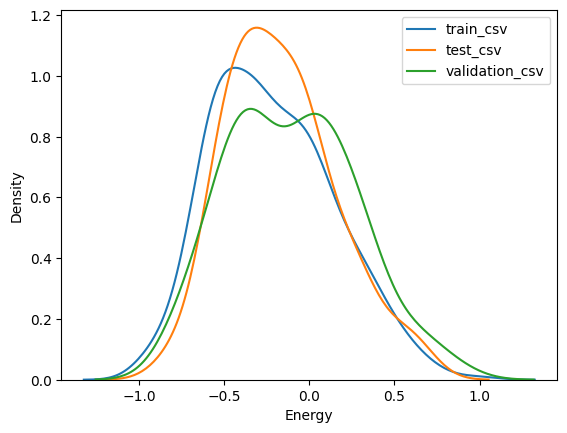

In [7]:
for idx in data_csv.keys():
    sns.kdeplot(new_df[idx]['Energy'], label=idx)
plt.legend()

<Axes: xlabel='delta_G', ylabel='Density'>

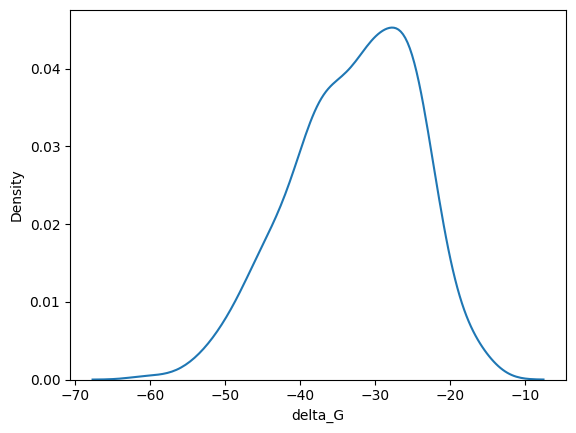

In [ ]:
sns.kdeplot(train_csv['delta_G'],)

<Axes: xlabel='delta_G', ylabel='Density'>

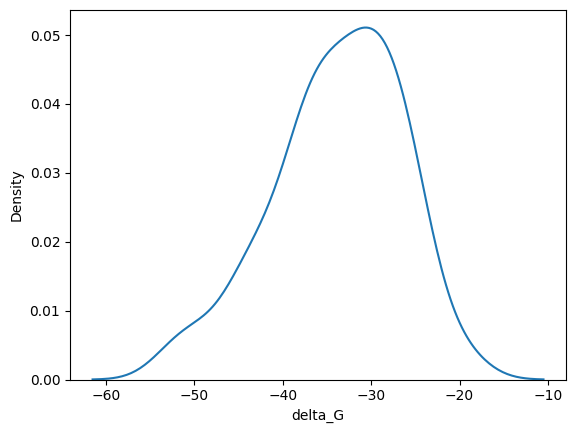

In [8]:
sns.kdeplot(test_csv['delta_G'])

<Axes: xlabel='delta_G', ylabel='Density'>

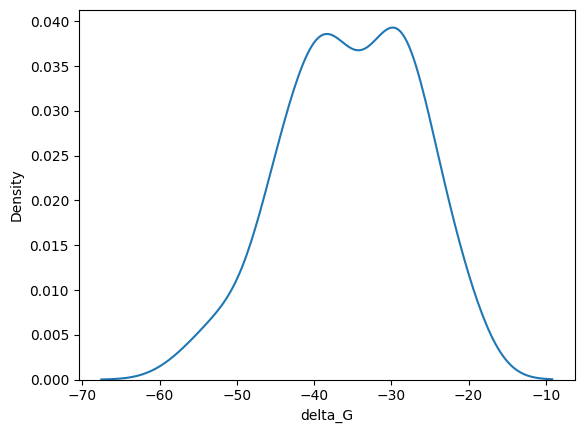

In [9]:
sns.kdeplot(validation_csv['delta_G'])